In [27]:
%run -i ../../utils.ipynb

In much of what is to follow, we will be working with Gaussian PDFs.
In one dimension, a Gaussian PDF is given by

$$p(x|\mu, \sigma^2) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{1}{2}\frac{(x-\mu)^2}{\sigma^2}\right), \tag{2.42}$$

where $\mu$ is the *mean* and $\sigma^2$ is the *variance* ($\sigma$ is called the *standard deviation*).

In [28]:
def _make_gaussian_pdf(mu, sigma):
  def _p(x):
    return (
      1 / math.sqrt(2 * math.pi * (sigma ** 2))
    ) * math.exp(
      (-1 / 2) * (((x - mu) ** 2) / (sigma ** 2))
    )
  return _p

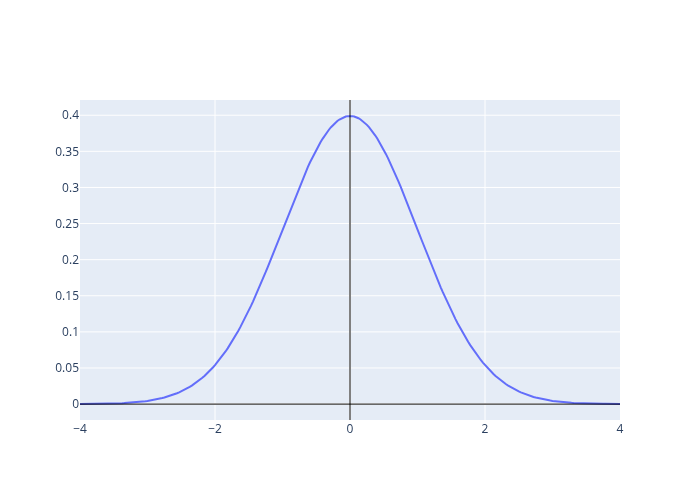

In [29]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _CRV(pdf=_make_gaussian_pdf(0.0, 1.0))
  _plot_function(x.pdf)

The *cumulative distribution function (CDF)* of a one-dimensional Gaussian is

$$P(x|\mu, \sigma^2) = \frac{1}{2} \left( 1 + \operatorname{erf} \left( \frac{x-\mu}{\sqrt{2}\sigma} \right) \right), \tag{2.43}$$

where $\operatorname{erf}(\cdot)$ is known as the *error function*,

$$\operatorname{erf}(z) = \frac{2}{\sqrt{\pi}} \int_{0}^{z} e^{-t^2} dt. \tag{2.44}$$

In [30]:
def _make_gaussian_cdf(mu, sigma):
  def erf(z):
    return (2 / (math.sqrt(math.pi))) * scipy.integrate.quad(
      (lambda t: math.exp(-1 * (t ** 2))), 0, z
    )[0]
  return lambda x: (
    (1 / 2) * (1 + erf((x - mu) / (math.sqrt(2) * sigma)))
  )

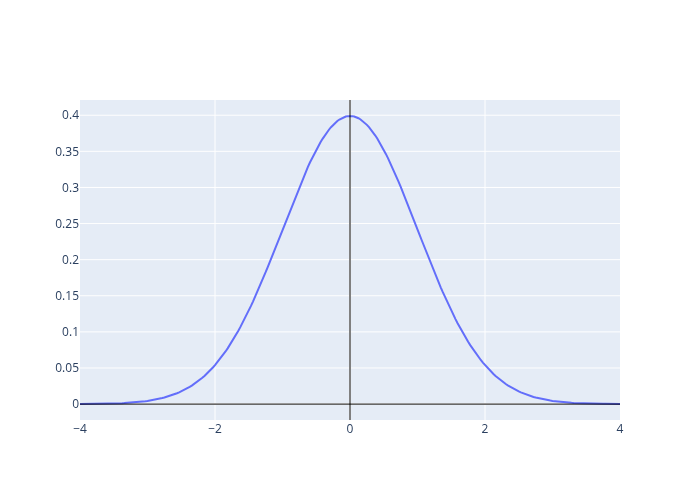

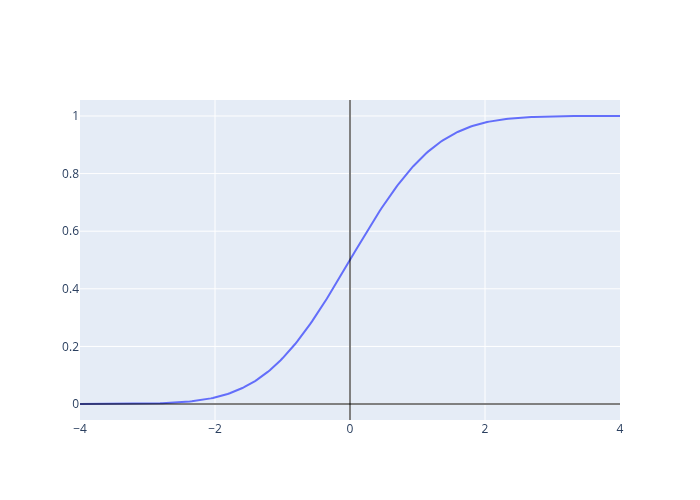

In [31]:
if __name__ == '__main__' and '__file__' not in globals():
  x = _CRV(pdf=_make_gaussian_pdf(0.0, 1.0),
           cdf=_make_gaussian_cdf(0.0, 1.0))
  _plot_function(x.pdf)
  _plot_function(x.cdf)